In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch

from src.dataset.kitti_dataset import KittiDataset
from src.preprocessing.bev import bev_projection
from src.models.bev_detector import BEVDetector

In [2]:
dataset = KittiDataset("../data/KITTI")

sample = dataset[1]

bev = bev_projection(
    sample["points"]
)

print(bev.shape)

(3, 350, 400)


In [3]:
bev_tensor = torch.from_numpy(
    bev
).float()
print(bev_tensor.shape)

torch.Size([3, 350, 400])


In [4]:
bev_tensor = bev_tensor.unsqueeze(0)

print(bev_tensor.shape)

torch.Size([1, 3, 350, 400])


In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [6]:
model = BEVDetector().to(device)

bev_tensor = bev_tensor.to(device)

In [7]:
model.eval()

with torch.no_grad():
    outputs = model(bev_tensor)

In [8]:
for name, tensor in outputs.items():
    print(name, tensor.shape)

heatmap torch.Size([1, 1, 350, 400])
offset torch.Size([1, 2, 350, 400])
size torch.Size([1, 2, 350, 400])
rotation torch.Size([1, 2, 350, 400])


In [9]:

from src.dataset.kitti_dataset import KittiDataset
from src.preprocessing.bev import bev_projection

from src.geometry.boxes import (
    create_box_corners_camera,
    box_parameters_from_lidar_corners,
    get_lidar_boxes
)

from src.geometry.transforms import (
    rectified_camera_to_lidar
)

from src.targets.bev_targets import (
    create_bev_targets
)

In [10]:
points = sample["points"]
labels = sample["labels"]
calib = sample["calib"]

bev = bev_projection(points)

In [11]:
boxes = get_lidar_boxes(
    labels,
    calib
)

In [12]:
targets_np = create_bev_targets(boxes)

In [13]:
import torch
target_tensors = {
    "heatmap": torch.from_numpy(
        targets_np["heatmap"]
    ).float().unsqueeze(0).unsqueeze(0),

    "offset": torch.from_numpy(
        targets_np["offset"]
    ).float().unsqueeze(0),

    "size": torch.from_numpy(
        targets_np["size"]
    ).float().unsqueeze(0),

    "rotation": torch.from_numpy(
        targets_np["rotation"]
    ).float().unsqueeze(0),

    "regression_mask": torch.from_numpy(
        targets_np["regression_mask"]
    ).float().unsqueeze(0).unsqueeze(0)
}

In [14]:
target_tensors = {
    key: value.to(device)
    for key, value in target_tensors.items()
}

In [15]:
from src.losses.detection_loss import DetectionLoss

criterion = DetectionLoss().to(device)

model.train()

predictions = model(bev_tensor)

losses = criterion(
    predictions,
    target_tensors
)

for name, value in losses.items():
    print(
        name,
        value.item()
    )

total 38005.08984375
heatmap 37996.6328125
offset 1.685831069946289
size 5.315548896789551
rotation 1.452045202255249


In [16]:
print("mask sum:",
      target_tensors["regression_mask"].sum().item())

print("heatmap positives:",
      target_tensors["heatmap"].sum().item())

mask sum: 1.0
heatmap positives: 4.3504533767700195


In [17]:
import numpy as np
targets_np = create_bev_targets(boxes)

print(
    "heatmap sum:",
    targets_np["heatmap"].sum()
)

print(
    "regression mask sum:",
    targets_np["regression_mask"].sum()
)

print(
    "non-zero offset values:",
    np.count_nonzero(targets_np["offset"])
)

print(
    "non-zero size values:",
    np.count_nonzero(targets_np["size"])
)

print(
    "non-zero rotation values:",
    np.count_nonzero(targets_np["rotation"])
)

heatmap sum: 4.3504534
regression mask sum: 1.0
non-zero offset values: 2
non-zero size values: 2
non-zero rotation values: 2


In [18]:
indices = np.argwhere(
    targets_np["regression_mask"] > 0
)

print(indices)

[[293 282]]


In [19]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

history = []

model.train()

for step in range(300):

    optimizer.zero_grad()

    predictions = model(bev_tensor)

    losses = criterion(
        predictions,
        target_tensors
    )

    loss = losses["total"]

    loss.backward()

    optimizer.step()

    history.append({
        "total": loss.item(),
        "heatmap": losses["heatmap"].item(),
        "offset": losses["offset"].item(),
        "size": losses["size"].item(),
        "rotation": losses["rotation"].item()
    })

    if step % 20 == 0:
        print(
            f"step {step:03d} | "
            f"total {loss.item():.4f} | "
            f"heatmap {losses['heatmap'].item():.4f} | "
            f"offset {losses['offset'].item():.4f} | "
            f"size {losses['size'].item():.4f} | "
            f"rotation {losses['rotation'].item():.4f}"
        )

step 000 | total 38005.0898 | heatmap 37996.6328 | offset 1.6858 | size 5.3155 | rotation 1.4520
step 020 | total 7758.4307 | heatmap 7750.9995 | offset 1.1791 | size 5.2135 | rotation 1.0383
step 040 | total 3501.8906 | heatmap 3495.9390 | offset 0.6555 | size 4.6185 | rotation 0.6776
step 060 | total 2097.3669 | heatmap 2092.8503 | offset 0.0721 | size 4.0464 | rotation 0.3981
step 080 | total 1384.4366 | heatmap 1380.9834 | offset 0.0135 | size 3.3769 | rotation 0.0628
step 100 | total 980.1769 | heatmap 977.4921 | offset 0.0084 | size 2.6700 | rotation 0.0064
step 120 | total 730.3765 | heatmap 728.3724 | offset 0.0057 | size 1.9896 | rotation 0.0088
step 140 | total 563.6894 | heatmap 562.0615 | offset 0.0067 | size 1.6200 | rotation 0.0011
step 160 | total 445.9788 | heatmap 444.7387 | offset 0.0067 | size 1.2290 | rotation 0.0043
step 180 | total 361.5121 | heatmap 360.6756 | offset 0.0023 | size 0.8315 | rotation 0.0026
step 200 | total 298.6957 | heatmap 298.2632 | offset 0.00

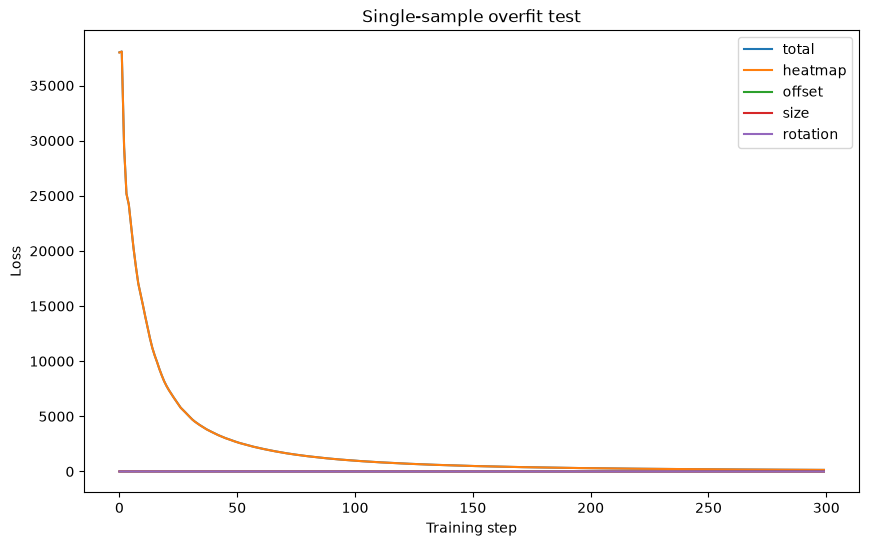

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    [x["total"] for x in history],
    label="total"
)

plt.plot(
    [x["heatmap"] for x in history],
    label="heatmap"
)

plt.plot(
    [x["offset"] for x in history],
    label="offset"
)

plt.plot(
    [x["size"] for x in history],
    label="size"
)

plt.plot(
    [x["rotation"] for x in history],
    label="rotation"
)

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Single-sample overfit test")
plt.legend()

plt.show()

In [21]:
from src.dataset.kitti_dataset import KittiDataset

dataset = KittiDataset("../data/KITTI")

bev, targets = dataset.get_training_sample(10)

print(bev.shape)
print(targets["heatmap"].shape)
print(targets["offset"].shape)
print(targets["size"].shape)
print(targets["rotation"].shape)
print(targets["regression_mask"].shape)

(3, 350, 400)
(350, 400)
(2, 350, 400)
(2, 350, 400)
(2, 350, 400)
(350, 400)


In [22]:
def create_batch(dataset, indices, device):

    bev_batch = []

    heatmap_batch = []
    offset_batch = []
    size_batch = []
    rotation_batch = []
    mask_batch = []

    for idx in indices:

        # Already does:
        # points -> BEV
        # labels -> lidar boxes -> targets
        bev, targets = dataset.get_training_sample(idx)

        # -----------------------------
        # Input
        # -----------------------------

        bev_batch.append(
            torch.from_numpy(bev).float()
        )

        # -----------------------------
        # Targets
        # -----------------------------

        heatmap_batch.append(
            torch.from_numpy(
                targets["heatmap"]
            ).float().unsqueeze(0)
        )

        offset_batch.append(
            torch.from_numpy(
                targets["offset"]
            ).float()
        )

        size_batch.append(
            torch.from_numpy(
                targets["size"]
            ).float()
        )

        rotation_batch.append(
            torch.from_numpy(
                targets["rotation"]
            ).float()
        )

        mask_batch.append(
            torch.from_numpy(
                targets["regression_mask"]
            ).float().unsqueeze(0)
        )

    # Stack different samples along batch dimension

    bev_batch = torch.stack(
        bev_batch,
        dim=0
    ).to(device)

    targets_batch = {
        "heatmap": torch.stack(
            heatmap_batch, dim=0
        ).to(device),

        "offset": torch.stack(
            offset_batch, dim=0
        ).to(device),

        "size": torch.stack(
            size_batch, dim=0
        ).to(device),

        "rotation": torch.stack(
            rotation_batch, dim=0
        ).to(device),

        "regression_mask": torch.stack(
            mask_batch, dim=0
        ).to(device),
    }

    return bev_batch, targets_batch

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

bev_batch, targets_batch = create_batch(
    dataset,
    indices=[1, 2, 3, 4],
    device=device
)

print("BEV:", bev_batch.shape)

for name, tensor in targets_batch.items():
    print(name, tensor.shape)

BEV: torch.Size([4, 3, 350, 400])
heatmap torch.Size([4, 1, 350, 400])
offset torch.Size([4, 2, 350, 400])
size torch.Size([4, 2, 350, 400])
rotation torch.Size([4, 2, 350, 400])
regression_mask torch.Size([4, 1, 350, 400])


In [24]:
print(dataset.velodyne_dir)
print(dataset.velodyne_dir.exists())
print(len(dataset))

../data/KITTI/training/velodyne
True
7481


In [26]:
from pathlib import Path

import torch

from src.dataset.kitti_dataset import KittiDataset
from src.models.bev_detector import BEVDetector
from src.losses.detection_loss import DetectionLoss


# =========================================================
# Configuration
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

EPOCHS = 30
BATCH_SIZE = 4
LEARNING_RATE = 1e-3


# =========================================================
# Dataset
# =========================================================

dataset = KittiDataset(
    "data/KITTI"
)


# =========================================================
# Model
# =========================================================

model = BEVDetector().to(device)

criterion = DetectionLoss().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# =========================================================
# Select small training subset
# =========================================================

training_indices = list(range(50))


# =========================================================
# Training
# =========================================================

history = []

model.train()

for epoch in range(EPOCHS):

    epoch_loss = 0.0
    num_batches = 0

    for start in range(
        0,
        len(training_indices),
        BATCH_SIZE
    ):

        batch_indices = training_indices[
            start:start + BATCH_SIZE
        ]

        bev_batch, targets_batch = create_batch(
            dataset,
            batch_indices,
            device
        )

        # -----------------------------
        # Reset old gradients
        # -----------------------------

        optimizer.zero_grad()

        # -----------------------------
        # Forward
        # -----------------------------

        predictions = model(
            bev_batch
        )

        # -----------------------------
        # Loss
        # -----------------------------

        losses = criterion(
            predictions,
            targets_batch
        )

        loss = losses["total"]

        # -----------------------------
        # Backpropagation
        # -----------------------------

        loss.backward()

        # -----------------------------
        # Weight update
        # -----------------------------

        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    average_loss = (
        epoch_loss / num_batches
    )

    history.append(
        average_loss
    )

    print(
        f"Epoch {epoch + 1:03d}/{EPOCHS} | "
        f"Loss: {average_loss:.4f}"
    )

IndexError: list index out of range